In [6]:
from dotenv import load_dotenv

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import dlib

from pathlib import Path

from tqdm import tqdm

from typing import List, Literal



In [90]:
class PathManager:
    """환경 및 모듈 간 규격 클래스"""
    """상황에 맞게 경로와 규격을 수정 후 사용할 것"""
    
    def __init__(self, default_size: int):
        """dotenv 위치 찾기 + 로드"""
        self.root_path = self._find_root()
        self.dotenv_path = self.root_path / ".env" # 또는 self.dotenv_path = self.root_path / ".env"
        load_dotenv(self.dotenv_path)

        """이미지와 모델 디렉토리 인식"""
        self._images_dir = self.root_path / "Computer_Vision/CV01/data/images"
        self._models_dir = self.root_path / "Computer_Vision/models"
        self.default_size = default_size

        self.image_name = None
        self.model_name = None

    def _find_root(self, marker: str=".env") -> Path:
        """프로젝트 최상단 경로를 찾는 함수"""
        """.env를 마커로 사용"""
        current_cwd = Path().cwd().resolve()
        for parent in current_cwd.parents:
            if (parent / marker).exists():
                return parent

    def get_image_path(self, image_name: str) -> Path:
        """이미지 주소 획득"""
        self.image_name = image_name
        return self._images_dir / image_name
        
    def get_model_path(self, model_name: str) -> Path:
        """모델 주소 획득"""
        self.model_name = model_name
        return self._models_dir / model_name


class Accessories:
    """앵커를 악세사리 분류별로 배치할 수 있게 하기 위함"""

    def __init__(self):
        self.acc = {
            "hero.png": "top",
            "king.png": "top",
            "glasses.png": "middle",
            "sunglasses.png": "middle",
            "mustache.png": "middle",
            "muffler.png": "bottom"
        }
        self.deleted_acc = None

    def add_acc(self, acc, position: Literal["top", "middle", "bottom"]):
        """분류는 top middle bottom 세 가지만 가능"""
        """try문 추가 필요"""
        self.acc[acc] = position
        print(f"{acc} 추가 완료")

    def del_acc(self, acc):
        self.deleted_acc = self.acc.pop(acc)
        print(f"{self.deleted_acc} 삭제 완료")


class ImageLoader:
    """이미지 로더: 경로 문제 생길 시 Config클래스 확인"""

    def __init__(self, image_path):
        self.img_bgr = cv2.imread(image_path, -1)
        self.img_bgr_copy = self.img_bgr.copy()
        self.img_rgb = cv2.cvtColor(self.img_bgr, cv2.COLOR_BGR2RGB)
        self.img_rgb_copy = self.img_rgb.copy()
    
    def show_image(self):
        plt.imshow(self.img_rgb)
        plt.show()


class FaceLoader(ImageLoader):
    """얼굴 로더: 이미지 로더 상속"""

    def __init__(self, face_path):
        super().__init__(face_path)
        self.detector_hog = dlib.get_frontal_face_detector()
        self.dlib_rects = None
        self.list_dlib_rects = []

    def get_box(self) -> List[dlib.rectangle]:
        self.dlib_rects = self.detector_hog(self.img_rgb, 1)

    def draw_box(self):
        for dlib_rect in self.dlib_rects:
            left = dlib_rect.left()
            top = dlib_rect.top()
            right = dlib_rect.right()
            bottom = dlib_rect.bottom()

            cv2.rectangle(self.img_rgb, (left, top), (right, bottom), (60, 255, 60), 2, lineType=cv2.LINE_8)
            self.list_dlib_rects.append([left, top, right, bottom])
            super().show_image()
        print(f"찾은 얼굴 개수: {len(self.list_dlib_rects)}")
        print(f"바인드 박스의 크기: {(self.list_dlib_rects[0][2] - self.list_dlib_rects[0][0] + 1), (self.list_dlib_rects[0][3] - self.list_dlib_rects[0][1] + 1), 3}")


class StickerLoader(ImageLoader):
    """스티커 로더: 이미지 로더 상속"""
    
    def __init__(self, sticker_path):
        super().__init__(sticker_path)
    
    def show_sticker(self):
        super().show_image()


class BaseModel:
    """얼굴인식 모델 모음용"""
    def __init__(self, model_path):
        self.model_path = model_path
        self.list_landmarks = []
        self.list_points = []


class ShapePredictor(BaseModel):
    """예제 모델"""
    
    def __init__(self, model_path):
        super().__init__(model_path)
        self.landmark_predictor = dlib.shape_predictor(str(self.model_path))

    def get_landmarks(self, image_rgb, dlib_rects):
        """랜드마크 리스트들의 각 리스트 안에는 68개의 랜드마크 포인트들이 들어있음"""
        for dlib_rect in dlib_rects:
            points = self.landmark_predictor(image_rgb, dlib_rect)
            self.list_points = list(map(lambda p: (p.x, p.y), points.parts()))
            self.list_landmarks.append(self.list_points)

    def draw_landmarks(self, image_rgb):
        for landmark in self.list_landmarks:
            for point in self.list_points:
                cv2.circle(image_rgb, point, 2, (255, 255, 60), -1)

        plt.imshow(image_rgb)        
        plt.show()
        print(f"찾은 랜드마크 세트의 개수: {len(self.list_landmarks)}")
        print(f"랜드마크 세트에 들어있는 포인트의 개수: {len(self.list_landmarks)}")


class StickerAttaching:
    
    def __init__(self, sticker_path: Path):
        """Path 객체와 List 객체를 인자로 받음"""

        self.img_bgr = cv2.imread(sticker_path, -1)
        self.img_rgb = cv2.cvtColor(self.img_bgr, cv2.COLOR_BGR2RGB)
        self.resized_sticker = None
        self.x = 0
        self.y = 0
        self.w = 0
        self.h = 0
        self.refined_x = 0
        self.refined_y = 0

    def resize_sticker(self, dlib_rects):
        # self.resized_sticker = cv2.resize(self.img_rgb, (dlib_rects[0].right() - dlib_rects[0].left(), dlib_rects[0].bottom() - dlib_rects[0].top()))
        self.resized_sticker = cv2.resize(self.img_rgb, (dlib_rects[0].width(), dlib_rects[0].height()))
        plt.imshow(self.resized_sticker)
        plt.show()
        print(f"리사이징된 이미지 크기: {self.resized_sticker.shape}")

    def relocate_anchor(self, acc, sticker_name, dlib_rects, list_landmarks):
        for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
            # 1. 기준점은 오직 코(Index 30)의 실제 좌표로 고정
            base_x = landmark[30][0]
            base_y = landmark[30][1]
            
            self.w = dlib_rect.width()
            self.h = dlib_rect.height()

            # 2. X축은 모든 악세서리 공통 (중앙 정렬)
            self.refined_x = base_x - self.w // 2

            # 3. Y축은 카테고리별로 코(base_y) 기준 상대 좌표 계산
            position = acc.get(sticker_name)
            
            if position == "top":
                # 왕관: 코에서 얼굴 높이(h)만큼 위로
                self.refined_y = base_y - self.h - (self.h // 2)
            elif position == "middle":
                # 콧수염/안경: 코 위치 그대로 또는 미세 조정
                # 콧수염이라면 코 바로 아래여야 하므로 base_y 근처가 적당함
                self.refined_y = base_y - self.h // 2
            elif position == "bottom":
                # 머플러: 코에서 얼굴 높이 절반만큼 아래로
                self.refined_y = base_y + self.h // 2

            self.w = dlib_rect.width() # 얼굴 영역의 가로를 차지하는 픽셀의 수 (107-45+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
            self.h = dlib_rect.height()

            if self.refined_x < 0:
                self.resized_sticker = self.resized_sticker[:, -self.refined_x:]
                self.refined_x = 0
            # 왕관 이미지를 씌우기 위해 왕관 이미지가 시작할 y좌표 값 조정
            if self.refined_y < 0:
                self.resized_sticker = self.resized_sticker[-self.refined_y:, :] # refined_y가 -98이므로, img_sticker[98: , :]가 된다. (187, 187, 3)에서 (89, 187, 3)이 됨 (187개 중에서 98개가 잘려나감)
                self.refined_y = 0

    def attach_sticker(self, face_image):
        self.sticker_area = face_image[self.refined_y:self.refined_y+self.resized_sticker.shape[0], self.refined_x:self.refined_x+self.resized_sticker.shape[1]]

        face_image[self.refined_y:self.refined_y+self.resized_sticker.shape[0], self.refined_x:self.refined_x+self.resized_sticker.shape[1]] = np.where(self.resized_sticker==0,self.sticker_area,self.resized_sticker).astype(np.uint8)
        print (f"예상 부착지점: ({self.refined_x},{self.refined_y})")

    def show_result(self, face_image):
        plt.imshow(face_image)
        plt.show()

    def adjust_sticker_position(self, command):
        if command == "up":
            self.refined_y -= 3
        elif command == "down":
            self.refined_y += 3

        if self.refined_x < 0:
            self.resized_sticker = self.resized_sticker[:, -self.refined_x:]
            self.refined_x = 0
        # 왕관 이미지를 씌우기 위해 왕관 이미지가 시작할 y좌표 값 조정
        if self.refined_y < 0:
            self.resized_sticker = self.resized_sticker[-self.refined_y:, :] # refined_y가 -98이므로, img_sticker[98: , :]가 된다. (187, 187, 3)에서 (89, 187, 3)이 됨 (187개 중에서 98개가 잘려나감)
            self.refined_y = 0

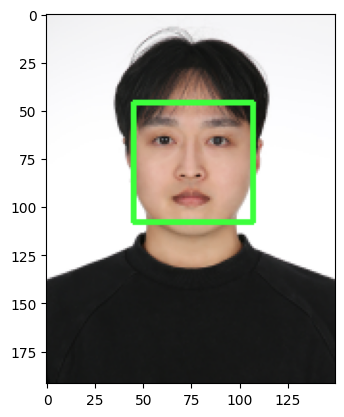

찾은 얼굴 개수: 1
바인드 박스의 크기: (63, 63, 3)


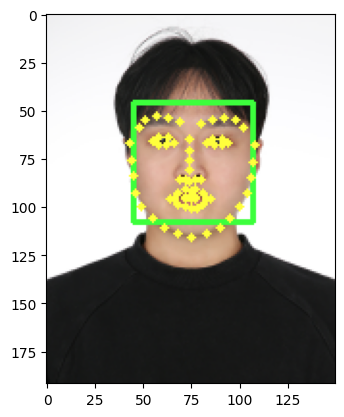

찾은 랜드마크 세트의 개수: 1
랜드마크 세트에 들어있는 포인트의 개수: 1


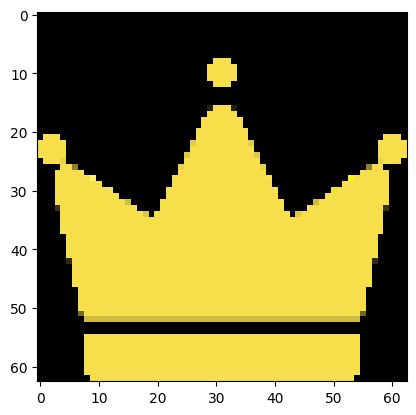

리사이징된 이미지 크기: (63, 63, 3)
예상 부착지점: (43,0)


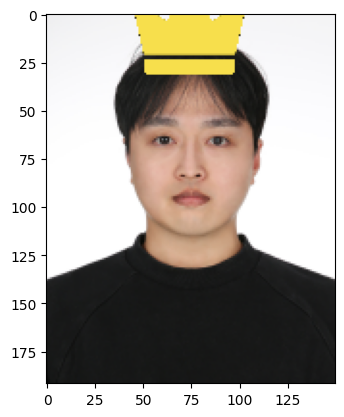

In [99]:
# 선글라스

def run():
    path_manager = PathManager(63)
    face_path = path_manager.get_image_path("me.png")
    model_path = path_manager.get_model_path("shape_predictor_68_face_landmarks.dat")
    sticker_path = path_manager.get_image_path("king.png")

    face_pic1 = FaceLoader(face_path)
    face_pic1.get_box()
    face_pic1.draw_box()

    shape_predictor = ShapePredictor(model_path)
    shape_predictor.get_landmarks(face_pic1.img_rgb, face_pic1.dlib_rects)
    shape_predictor.draw_landmarks(face_pic1.img_rgb)

    accessories = Accessories()

    crown = StickerAttaching(sticker_path)
    crown.resize_sticker(face_pic1.dlib_rects)
    crown.relocate_anchor(accessories.acc, path_manager.image_name, face_pic1.dlib_rects, shape_predictor.list_landmarks)

    # # 위치를 조절할 필요가 없다면 이 부분을 주석 해제
    # crown.attach_sticker(face_pic1.img_rgb_copy)

    # 조정할 필요가 있다면 위를 주석처리 한 후 이 부분을 실행
    crown.adjust_sticker_position("up")
    crown.adjust_sticker_position("up")
    crown.adjust_sticker_position("up")
    crown.adjust_sticker_position("up")
    crown.adjust_sticker_position("up")    
    crown.adjust_sticker_position("up")
    crown.attach_sticker(face_pic1.img_rgb_copy)

    # 결과 확인 
    crown.show_result(face_pic1.img_rgb_copy)

run()

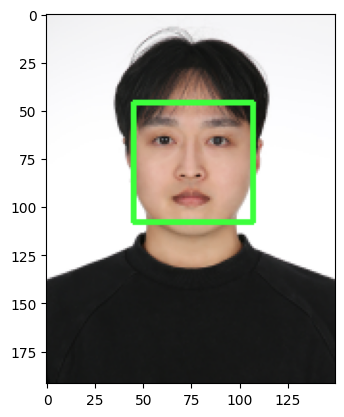

찾은 얼굴 개수: 1
바인드 박스의 크기: (63, 63, 3)


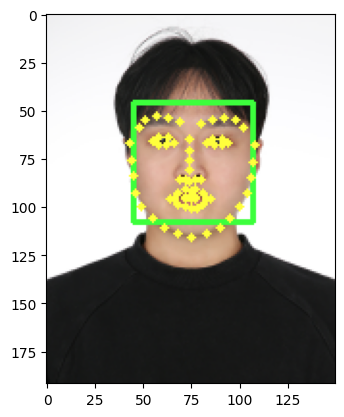

찾은 랜드마크 세트의 개수: 1
랜드마크 세트에 들어있는 포인트의 개수: 1


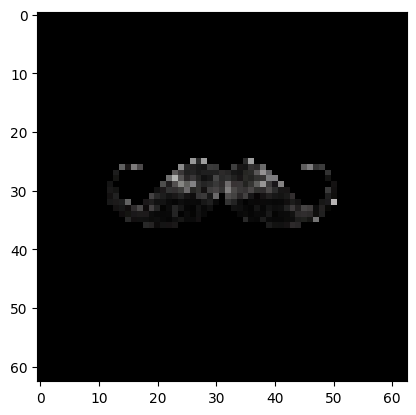

리사이징된 이미지 크기: (63, 63, 3)
예상 부착지점: (43,62)


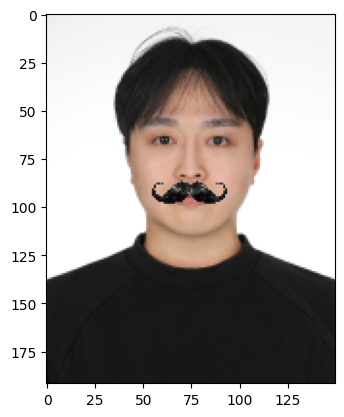

In [102]:
def run():
    path_manager = PathManager(63)
    face_path = path_manager.get_image_path("me.png")
    model_path = path_manager.get_model_path("shape_predictor_68_face_landmarks.dat")
    sticker_path = path_manager.get_image_path("mustache.png")

    face_pic1 = FaceLoader(face_path)
    face_pic1.get_box()
    face_pic1.draw_box()

    shape_predictor = ShapePredictor(model_path)
    shape_predictor.get_landmarks(face_pic1.img_rgb, face_pic1.dlib_rects)
    shape_predictor.draw_landmarks(face_pic1.img_rgb)

    accessories = Accessories()

    crown = StickerAttaching(sticker_path)
    crown.resize_sticker(face_pic1.dlib_rects)
    crown.relocate_anchor(accessories.acc, path_manager.image_name, face_pic1.dlib_rects, shape_predictor.list_landmarks)

    # # 위치를 조절할 필요가 없다면 이 부분을 주석 해제
    # crown.attach_sticker(face_pic1.img_rgb)

    # 조정할 필요가 있다면 위를 주석처리 한 후 이 부분을 실행
    crown.adjust_sticker_position("down")
    crown.adjust_sticker_position("down")
    crown.adjust_sticker_position("down")
    crown.adjust_sticker_position("down")
    crown.attach_sticker(face_pic1.img_rgb_copy)

    # 결과 확인 
    crown.show_result(face_pic1.img_rgb_copy)

run()

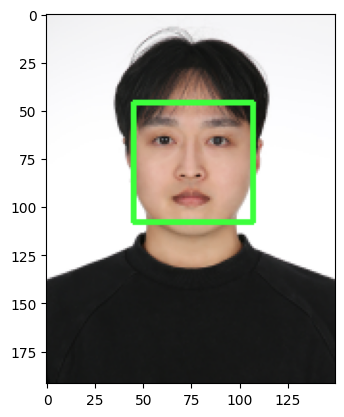

찾은 얼굴 개수: 1
바인드 박스의 크기: (63, 63, 3)


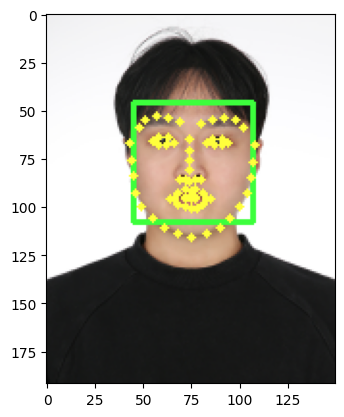

찾은 랜드마크 세트의 개수: 1
랜드마크 세트에 들어있는 포인트의 개수: 1


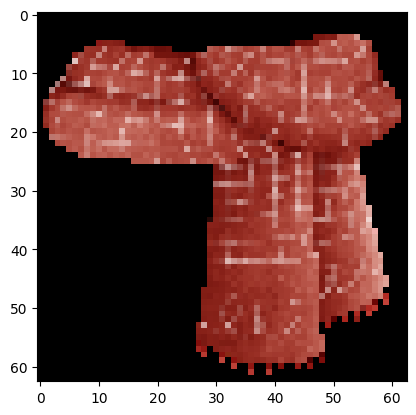

리사이징된 이미지 크기: (63, 63, 3)
예상 부착지점: (43,106)


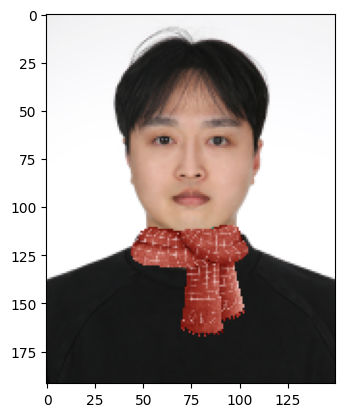

In [105]:
def run():
    path_manager = PathManager(63)
    face_path = path_manager.get_image_path("me.png")
    model_path = path_manager.get_model_path("shape_predictor_68_face_landmarks.dat")
    sticker_path = path_manager.get_image_path("muffler.png")

    face_pic1 = FaceLoader(face_path)
    face_pic1.get_box()
    face_pic1.draw_box()

    shape_predictor = ShapePredictor(model_path)
    shape_predictor.get_landmarks(face_pic1.img_rgb, face_pic1.dlib_rects)
    shape_predictor.draw_landmarks(face_pic1.img_rgb)

    accessories = Accessories()

    crown = StickerAttaching(sticker_path)
    crown.resize_sticker(face_pic1.dlib_rects)
    crown.relocate_anchor(accessories.acc, path_manager.image_name, face_pic1.dlib_rects, shape_predictor.list_landmarks)

    # # 위치를 조절할 필요가 없다면 이 부분을 주석 해제
    # crown.attach_sticker(face_pic1.img_rgb_copy)

    # 조정할 필요가 있다면 위를 주석처리 한 후 이 부분을 실행
    crown.adjust_sticker_position("up")
    crown.adjust_sticker_position("up")
    crown.attach_sticker(face_pic1.img_rgb_copy)

    # 결과 확인 
    crown.show_result(face_pic1.img_rgb_copy)

run()